In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
larsen0966_sba_loans_case_data_set_path = kagglehub.dataset_download('larsen0966/sba-loans-case-data-set')

print('Data source import complete.')


Data source import complete.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/larsen0966/sba-loans-case-data-set/SBAcase.11.13.17.csv


In [3]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "SBAcase.11.13.17.csv"

df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "larsen0966/sba-loans-case-data-set",
  file_path,
)
display("First 5 records:", df.head())

/tmp/ipykernel_17/4058040613.py:6: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


'First 5 records:'

,Selected,LoanNr_ChkDgt,Name,City,State,Zip,Bank,BankState,NAICS,ApprovalDate,...,ChgOffPrinGr,GrAppv,SBA_Appv,New,RealEstate,Portion,Recession,daysterm,xx,Default
0,0,1004285007,SIMPLEX OFFICE SOLUTIONS,ANAHEIM,CA,92801,CALIFORNIA BANK & TRUST,CA,532420,15074,...,0,30000,15000,0,0,0.5,0,1080,16175.0,0
1,1,1004535010,DREAM HOME REALTY,TORRANCE,CA,90505,CALIFORNIA BANK & TRUST,CA,531210,15130,...,0,30000,15000,0,0,0.5,1,1680,17658.0,0
2,0,1005005006,"Winset, Inc. dba Bankers Hill",SAN DIEGO,CA,92103,CALIFORNIA BANK & TRUST,CA,531210,15188,...,0,30000,15000,0,0,0.5,0,1080,16298.0,0
3,1,1005535001,Shiva Management,SAN DIEGO,CA,92108,CALIFORNIA BANK & TRUST,CA,531312,15719,...,0,50000,25000,0,0,0.5,0,1080,16816.0,0
4,1,1005996006,"GOLD CROWN HOME LOANS, INC",LOS ANGELES,CA,91345,SBA - EDF ENFORCEMENT ACTION,CO,531390,16840,...,0,343000,343000,0,1,1.0,0,7200,24103.0,0


In [4]:
def dataDiscribtion(df):
    # Columns
    print("\n\nTotal Columns with name : ",df.columns)

    # Data information
    print("\n\nInformation of the data : ",df.info())

    # Data set shape
    print("\n\nDataset shape : ",df.shape)

    # Data null values
    display("\n\nDataset Null Values finding : ",df.isnull().sum())

    # Value counts
    print("\nValue counts")
    for column in df.columns:
        if df[column].dtype != 'int64':
            print(f"\n{column} unique values : ",df[column].nunique())
dataDiscribtion(df)



Total Columns with name :  Index(['Selected', 'LoanNr_ChkDgt', 'Name', 'City', 'State', 'Zip', 'Bank',
       'BankState', 'NAICS', 'ApprovalDate', 'ApprovalFY', 'Term', 'NoEmp',
       'NewExist', 'CreateJob', 'RetainedJob', 'FranchiseCode', 'UrbanRural',
       'RevLineCr', 'LowDoc', 'ChgOffDate', 'DisbursementDate',
       'DisbursementGross', 'BalanceGross', 'MIS_Status', 'ChgOffPrinGr',
       'GrAppv', 'SBA_Appv', 'New', 'RealEstate', 'Portion', 'Recession',
       'daysterm', 'xx', 'Default'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2102 entries, 0 to 2101
Data columns (total 35 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Selected           2102 non-null   int64  
 1   LoanNr_ChkDgt      2102 non-null   int64  
 2   Name               2102 non-null   object 
 3   City               2102 non-null   object 
 4   State              2102 non-null   object 
 5   Zip                210

'\n\nDataset Null Values finding : '

Selected                0
LoanNr_ChkDgt           0
Name                    0
City                    0
State                   0
Zip                     0
Bank                    3
BankState               3
NAICS                   0
ApprovalDate            0
ApprovalFY              0
Term                    0
NoEmp                   0
NewExist                1
CreateJob               0
RetainedJob             0
FranchiseCode           0
UrbanRural              0
RevLineCr               2
LowDoc                  3
ChgOffDate           1405
DisbursementDate        3
DisbursementGross       0
BalanceGross            0
MIS_Status              0
ChgOffPrinGr            0
GrAppv                  0
SBA_Appv                0
New                     0
RealEstate              0
Portion                 0
Recession               0
daysterm                0
xx                      3
Default                 0
dtype: int64


Value counts

Name unique values :  2005

City unique values :  519

State unique values :  1

Bank unique values :  154

BankState unique values :  21

NewExist unique values :  3

RevLineCr unique values :  4

LowDoc unique values :  5

ChgOffDate unique values :  503

DisbursementDate unique values :  321

MIS_Status unique values :  2

Portion unique values :  31

xx unique values :  1212


In [5]:
def dataCleaning(df):
    data = df.copy()

    # filling the 0
    data['ChgOffDate'] = data['ChgOffDate'].fillna(0)
    inconsistent_mask = (data['ChgOffDate'] != 0) & (data['Default'] == 0)
    data = data[~inconsistent_mask]

    # Droping the null values
    data = data.dropna(subset=['Bank','BankState','DisbursementDate','RevLineCr','LowDoc','NewExist'])

    # droping the data
    data = data.drop(columns=['State','ChgOffDate','Name','Zip','Selected','LoanNr_ChkDgt','xx','BalanceGross','MIS_Status','ChgOffPrinGr'],axis=1)

    print("\nThe final columns : ",data.columns)
    return data
cleanedData = dataCleaning(df)



The final columns :  Index(['City', 'Bank', 'BankState', 'NAICS', 'ApprovalDate', 'ApprovalFY',
       'Term', 'NoEmp', 'NewExist', 'CreateJob', 'RetainedJob',
       'FranchiseCode', 'UrbanRural', 'RevLineCr', 'LowDoc',
       'DisbursementDate', 'DisbursementGross', 'GrAppv', 'SBA_Appv', 'New',
       'RealEstate', 'Portion', 'Recession', 'daysterm', 'Default'],
      dtype='object')


In [6]:
def dataProcessing(df):
    data = df.copy()

    # Fiding the feature engineering ratio 
    data['Loan_Per_Employee'] = data['DisbursementGross'] / (data['NoEmp'] + 1)
    data['SBA_Ratio'] = data['SBA_Appv'] / (data['GrAppv'] + 1)
    data['Loan_to_Term'] = data['DisbursementGross'] / (data['Term'] + 1)
    data['Job_Efficiency'] = (data['CreateJob'] + data['RetainedJob']) / (data['NoEmp'] + 1)

    # Using count incording
    freq = data['City'].value_counts()
    data['city_freq'] = data['City'].map(freq)

    # Using count incording
    bank_freq = data['Bank'].value_counts()
    data['Bank_freq'] = data['Bank'].map(bank_freq)

    # Using count incording
    bank_freq = data['BankState'].value_counts()
    data['BankState_freq'] = data['BankState'].map(bank_freq)


    # RevLineCr
    data['RevLineCr'] = data['RevLineCr'].replace({
        'Y': 1,
        'T': 1,
        'N': 0,
        '0': 0
    })

    # LowDoc
    data['LowDoc'] = data['LowDoc'].replace({
        'Y': 1,
        'N': 0,
        'S': 0,
        'A': 0,
        '0': 0
    })
    data = data.drop(columns=['City','Bank','BankState'],axis=1)

    data['NAICS_2'] = data['NAICS'] // 10000
    data.drop('NAICS', axis=1, inplace=True)

    # Base year feature
    data['Years_Since_1987_Approval'] = data['ApprovalFY'] - 1987
    data.drop(['ApprovalDate', 'DisbursementDate'], axis=1, inplace=True)

    print(data.info())

    outlier_cols = [
    "DisbursementGross",
    "GrAppv",
    "SBA_Appv",
    "Loan_Per_Employee",
    "NoEmp",
    "CreateJob",
    "RetainedJob",
    "Term"
]

# Remove outliers using IQR
    for col in outlier_cols:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        data[col] = np.clip(data[col], lower, upper)

    print("Shape after outlier removal:", data.shape)


    
    return data
processedData = dataProcessing(cleanedData)
display(processedData.head())

<class 'pandas.core.frame.DataFrame'>
Index: 2080 entries, 0 to 2100
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ApprovalFY                 2080 non-null   int64  
 1   Term                       2080 non-null   int64  
 2   NoEmp                      2080 non-null   int64  
 3   NewExist                   2080 non-null   float64
 4   CreateJob                  2080 non-null   int64  
 5   RetainedJob                2080 non-null   int64  
 6   FranchiseCode              2080 non-null   int64  
 7   UrbanRural                 2080 non-null   int64  
 8   RevLineCr                  2080 non-null   int64  
 9   LowDoc                     2080 non-null   int64  
 10  DisbursementGross          2080 non-null   int64  
 11  GrAppv                     2080 non-null   int64  
 12  SBA_Appv                   2080 non-null   int64  
 13  New                        2080 non-null   int64  
 1

/tmp/ipykernel_17/1102972783.py:24: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['RevLineCr'] = data['RevLineCr'].replace({
/tmp/ipykernel_17/1102972783.py:32: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['LowDoc'] = data['LowDoc'].replace({


,ApprovalFY,Term,NoEmp,NewExist,CreateJob,RetainedJob,FranchiseCode,UrbanRural,RevLineCr,LowDoc,...,Default,Loan_Per_Employee,SBA_Ratio,Loan_to_Term,Job_Efficiency,city_freq,Bank_freq,BankState_freq,NAICS_2,Years_Since_1987_Approval
0,2001,36,1,1.0,0,0,1,0,1,0,...,0,16406.000000,0.499983,886.810811,0.000000,28,94,975,53,14
1,2001,56,1,1.0,0,0,1,0,1,0,...,0,15000.000000,0.499983,526.315789,0.000000,14,94,975,53,14
2,2001,36,10,1.0,0,0,1,0,1,0,...,0,2727.272727,0.499983,810.810811,0.000000,110,94,975,53,14
3,2003,36,6,1.0,0,0,1,0,1,0,...,0,7142.857143,0.499990,1351.351351,0.000000,110,94,975,53,16
4,2006,240,17,1.0,3,11,1,1,0,0,...,0,5196.969697,0.999997,1423.236515,1.030303,160,35,57,53,19


In [7]:
data = processedData

Train Accuracy: 0.9800824175824175
Test Accuracy: 0.9423076923076923

Test Classification Report
              precision    recall  f1-score   support

           0       0.97      0.95      0.96       419
           1       0.90      0.93      0.91       205

    accuracy                           0.94       624
   macro avg       0.93      0.94      0.94       624
weighted avg       0.94      0.94      0.94       624



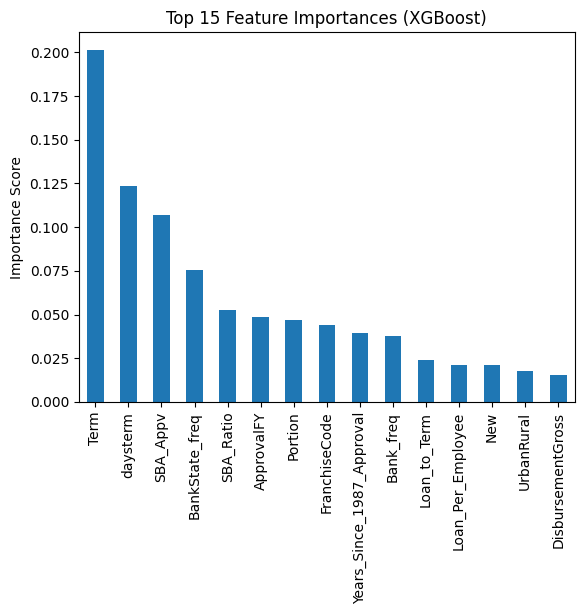

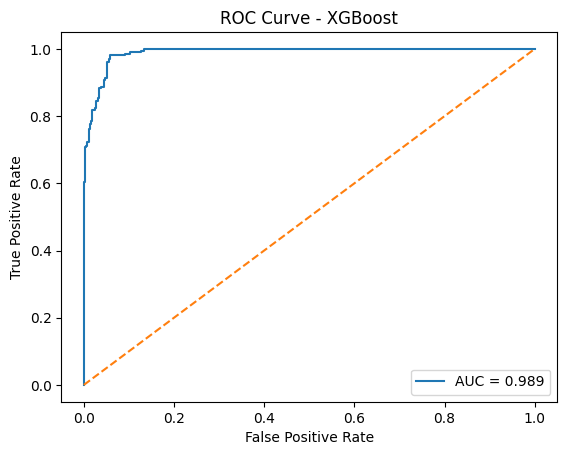

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_curve, roc_auc_score
from xgboost import XGBClassifier

X = data.drop('Default', axis=1)
y = data['Default']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

xgb_model = XGBClassifier(
    n_estimators=150,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=1,
    reg_lambda=2,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

train_preds = xgb_model.predict(X_train)
test_preds = xgb_model.predict(X_test)

train_acc = accuracy_score(y_train, train_preds)
test_acc = accuracy_score(y_test, test_preds)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

print("\nTest Classification Report")
print(classification_report(y_test, test_preds))

importances = xgb_model.feature_importances_
features = X.columns

feat_imp = pd.Series(importances, index=features)
feat_imp = feat_imp.sort_values(ascending=False)

plt.figure()
feat_imp.head(15).plot(kind='bar')
plt.title("Top 15 Feature Importances (XGBoost)")
plt.ylabel("Importance Score")
plt.show()

probs = xgb_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, probs)
auc_score = roc_auc_score(y_test, probs)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()
plt.show()


Confusion Matrix:
[[397  22]
 [ 14 191]]


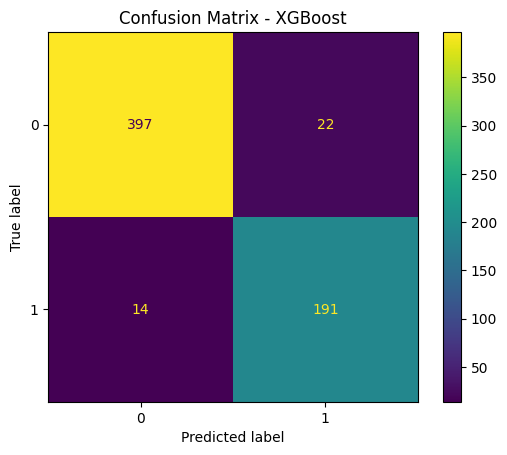

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# Predict
y_pred = xgb_model.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - XGBoost")
plt.show()